In [16]:
import torch
print(torch.cuda.is_available())

True


In [2]:
from dem_dataset import DEMTilesDataset

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"
mask_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

# Create dataset
dataset = DEMTilesDataset(
    dem_path=dem_path,
    mask_path=mask_path,
    tile_size=1024,
    stride=512
)

next(iter(dataset))

{'image': tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.6603, 0.6625, 0.6644],
          [0.0000, 0.0000, 0.0000,  ..., 0.6596, 0.6636, 0.6680],
          [0.0000, 0.0000, 0.0000,  ..., 0.6616, 0.6664, 0.6697]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.6603, 0.6625, 0.6644],
          [0.0000, 0.0000, 0.0000,  ..., 0.6596, 0.6636, 0.6680],
          [0.0000, 0.0000, 0.0000,  ..., 0.6616, 0.6664, 0.6697]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.00

In [3]:
print("Кол-во тайлов:", len(dataset))

Кол-во тайлов: 576


In [4]:
import torch
sample = dataset[1]
img, mask = sample["image"], sample["mask"]

print("image:", img.shape, img.dtype)   # ожидаем (3, T, T), float32
print("mask:", mask.shape, mask.dtype)  # ожидаем (T, T), int64
print("image min/max:", img.min().item(), img.max().item())
print("mask unique:", torch.unique(mask))

image: torch.Size([3, 1024, 1024]) torch.float32
mask: torch.Size([1024, 1024]) torch.int64
image min/max: 0.0 1.0
mask unique: tensor([  0,   1, 255])


In [5]:
import numpy as np

data = np.load(dem_path)
dem = data["dataset"]
valid = data["validMask"].astype(bool)

if mask_path.endswith(".npz"):
    mnpz = np.load(mask_path)
    # замените ключ на актуальный, если иной
    labels_arr = mnpz.get("labels_combined", mnpz.get("labels"))
else:
    labels_arr = np.load(mask_path)

print("DEM shape:", dem.shape)
print("VALID shape:", valid.shape)
print("MASK shape:", labels_arr.shape)
assert dem.shape == valid.shape == labels_arr.shape, "Размеры DEM/valid/mask должны совпадать"

DEM shape: (17092, 9791)
VALID shape: (17092, 9791)
MASK shape: (17092, 9791)


In [6]:
def check_many(dataset, n=16):
    issues = 0
    for i in range(min(n, len(dataset))):
        s = dataset[i]
        img, mask = s["image"], s["mask"]
        if img.shape[0] != 3:
            print(f"[{i}] Некорр. каналов: {img.shape}")
            issues += 1
        if img.dtype != torch.float32:
            print(f"[{i}] Некорр. dtype image: {img.dtype}")
            issues += 1
        if mask.dtype != torch.int64:
            print(f"[{i}] Некорр. dtype mask: {mask.dtype}")
            issues += 1
        u = torch.unique(mask)
        if not torch.all(torch.isin(u, torch.tensor([0,1,255], dtype=torch.long))):
            print(f"[{i}] Неожиданные значения маски: {u}")
            issues += 1
        if torch.isnan(img).any():
            print(f"[{i}] NaN в image")
            issues += 1
        if img.min() < -1e-4 or img.max() > 1.0001:
            print(f"[{i}] image вне [0,1]: min={img.min().item()} max={img.max().item()}")
            # не обязательно критично, но стоит знать
    print("Проверка завершена, проблем:", issues)

check_many(dataset, n=32)

Проверка завершена, проблем: 0


In [7]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)  # начните с 0, чтобы проще дебажить
batch = next(iter(loader))
imgs, masks = batch["image"], batch["mask"]
print("batch image:", imgs.shape, imgs.dtype)  # (B, 3, T, T)
print("batch mask:", masks.shape, masks.dtype) # (B, T, T)
print("mask unique in batch:", torch.unique(masks))

batch image: torch.Size([2, 3, 1024, 1024]) torch.float32
batch mask: torch.Size([2, 1024, 1024]) torch.int64
mask unique in batch: tensor([0, 1])


0


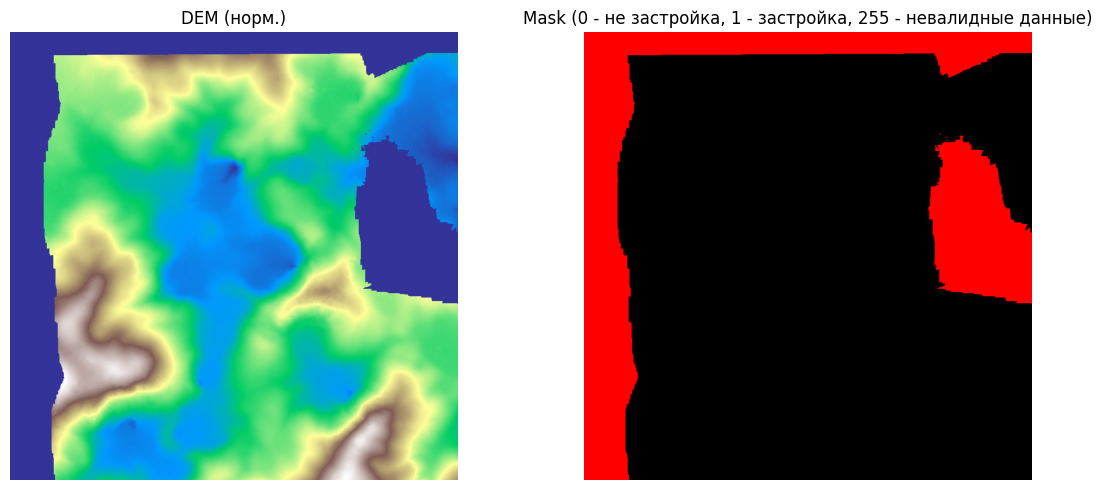

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

k = 0
s = dataset[k]
img = s["image"].numpy()  # (3, T, T)
mask = s["mask"].numpy()  # (T, T)
print(np.count_nonzero(mask == 1))

# Настраиваем списки цветов для каждого класса
# В данном случае 0 - не застройка, 1 - застройка, 255 - невалидные данные
colors = ['black', 'red', 'gray']
cmap = ListedColormap(colors[:len(np.unique(mask))])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img[0], cmap="terrain")  # один канал
plt.title("DEM (норм.)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap=cmap)
plt.title("Mask (0 - не застройка, 1 - застройка, 255 - невалидные данные)")
plt.axis("off")
plt.tight_layout()
plt.show()

Размер: (1024, 1024)
Классы в маске: [  0   1 255]
Кол-во пикселей класса 1: 1657


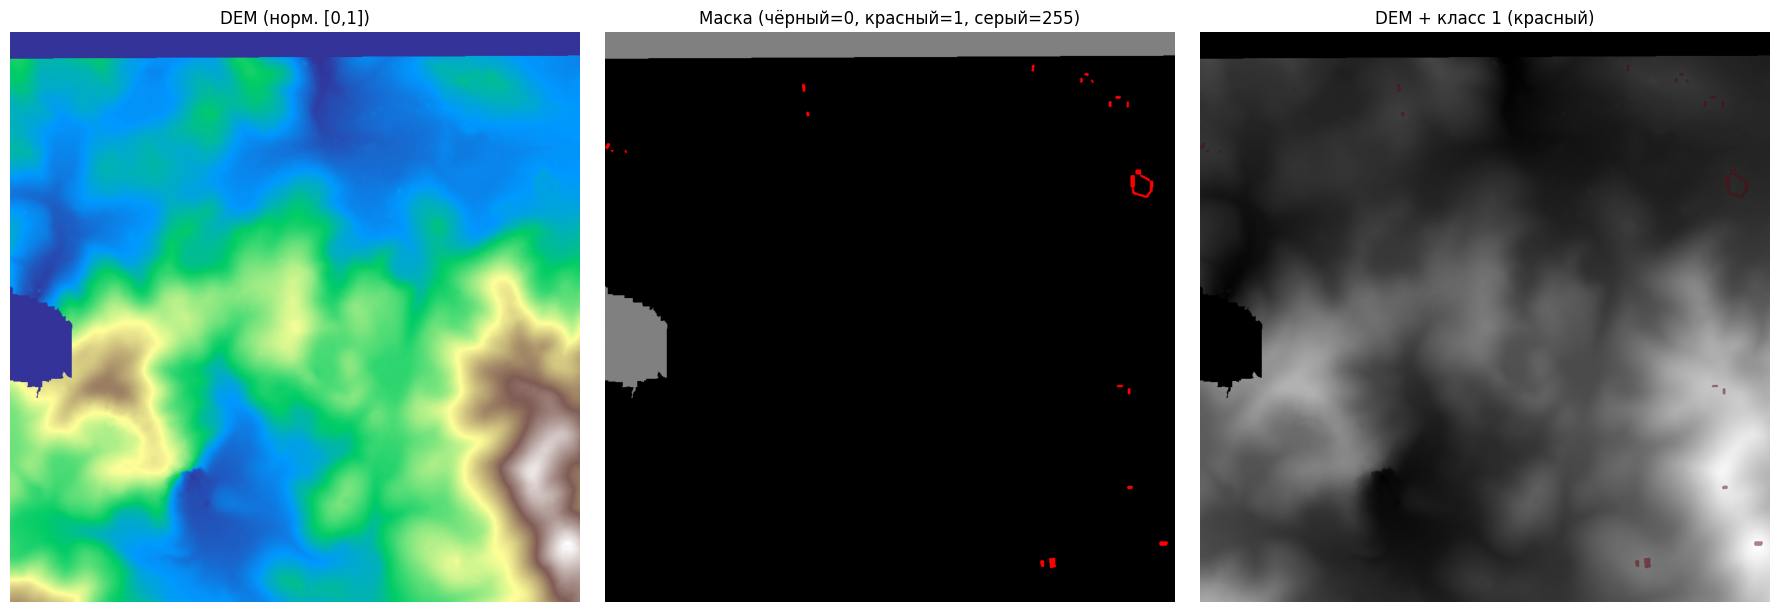

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def plot_sample(img, mask, alpha=0.5):
    """Визуализация DEM и маски с подкраской классов.
    
    Args:
        img: (3, H, W) - изображение DEM
        mask: (H, W) - маска с 0, 1, 255
        alpha: прозрачность наложения маски
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Только DEM
    ax1.imshow(img[0], cmap="terrain", vmin=0, vmax=1)
    ax1.set_title("DEM (норм. [0,1])")
    ax1.axis("off")
    
    # 2. Только маска
    cmap_mask = mcolors.ListedColormap(['black', 'red', 'gray'])
    bounds = [-1, 0.5, 1.5, 256]  # 0, 1, 255
    norm = mcolors.BoundaryNorm(bounds, cmap_mask.N)
    im = ax2.imshow(mask, cmap=cmap_mask, norm=norm)
    ax2.set_title("Маска (чёрный=0, красный=1, серый=255)")
    ax2.axis("off")
    
    # 3. DEM + маска (только класс 1)
    ax3.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    mask_vis = np.ma.masked_where(mask != 1, mask)
    ax3.imshow(mask_vis, cmap="Reds", alpha=alpha, vmin=0, vmax=1)
    ax3.set_title("DEM + класс 1 (красный)")
    ax3.axis("off")
    
    plt.tight_layout()
    plt.show()

# Пример использования
k = 2
s = dataset[k]
img = s["image"].numpy()  # (3, T, T)
mask = s["mask"].numpy()  # (T, T)

print(f"Размер: {mask.shape}")
print(f"Классы в маске: {np.unique(mask)}")
print(f"Кол-во пикселей класса 1: {np.count_nonzero(mask == 1)}")

plot_sample(img, mask)

In [10]:
import numpy as np
from collections import Counter

def class_stats(ds, sample_tiles=100):
    cnt = Counter()
    to_check = min(sample_tiles, len(ds))
    for i in range(to_check):
        m = ds[i]["mask"].numpy()
        vals, freqs = np.unique(m[m != 255], return_counts=True)
        for v, f in zip(vals, freqs):
            cnt[int(v)] += int(f)
    
    percents = {k: round(v / sum(cnt.values()), 7) for k, v in cnt.items()}
    return cnt, percents

print("Class balance (примерно):", class_stats(dataset, sample_tiles=576))

Class balance (примерно): (Counter({0: 593880007, 1: 1705656}), {0: 0.9971362, 1: 0.0028638})
